# Lab 4: Data Quality Assessment & Preprocessing

**Tasks:**
- **Task 1**: Identify data quality issues in the dataset.
- **Task 2**: Apply one missing value strategy and explain why.
- **Task 3**: Detect and handle outliers using IQR.
- **Task 4**: Normalize numerical features using both Min-Max and Z-score.
- **Task 5**: Apply PCA and interpret explained variance.


In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


## Task 1: Identify data quality issues in the dataset.


In [14]:
df = pd.read_csv("amazon.csv")

# Identifying missing values & data types
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isna().sum())

# Display the head to find anomalies
df.head()


--- Data Types ---
product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

--- Missing Values ---
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


**Data Quality Issues Identified:**
1. **Wrong Data Types:** Features like `discounted_price`, `actual_price`, `discount_percentage`, `rating`, and `rating_count` are stored as objects/strings instead of numeric types.
   - Prices have `₹` and commas (`,`).
   - Percentages have `%`.
   - Ratings might contain non-numeric strings (e.g. `|`).
   - Counts have commas (`,`).
2. **Missing Values:** `rating_count` has missing values (2 NaNs).
3. **Outliers:** Numerical columns might have extreme potential outliers.

Before proceeding, let's fix the data types:


In [15]:
# Preprocessing Data Types
# Removing commas and ₹ then converting to float
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# Coercing 'rating' to numeric (this turns anomalies like '|' into NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Converting 'rating_count'
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

df.dtypes


product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
about_product              str
user_id                    str
user_name                  str
review_id                  str
review_title               str
review_content             str
img_link                   str
product_link               str
dtype: object

## Task 2: Apply one missing value strategy and explain why.

After coercion to numeric, we might have newly formed missing values. We apply a strategy below:


In [16]:
print("Null Values before Imputation:")
print(df[['rating', 'rating_count']].isna().sum())

# Strategy using Median Imputation
df['rating'] = df['rating'].fillna(df['rating'].median())
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

print("\nNull Values after Imputation:")
print(df[['rating', 'rating_count']].isna().sum())


Null Values before Imputation:
rating          1
rating_count    2
dtype: int64

Null Values after Imputation:
rating          0
rating_count    0
dtype: int64


**Why Median Imputation?**
We chose **Median Imputation** for `rating` and `rating_count` because these variables correspond to user engagement and product evaluation, which can be highly skewed. Mean imputation is sensitive to extreme outliers (e.g., highly rated/viewed products generating millions of ratings versus average items having few), while the median provides a robust central disposition without being influenced heavily by extremely successful outlier products.


## Task 3: Detect and handle outliers using IQR.
We will analyze the `actual_price` feature to detect and handle outliers.


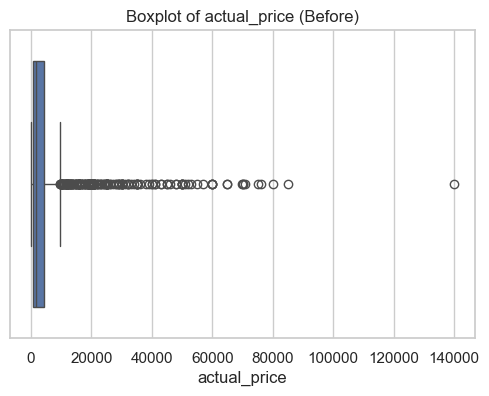

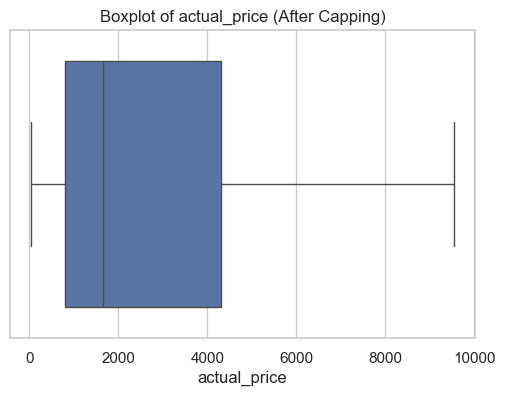

In [17]:
# Define the feature to check for outliers
col = 'actual_price'

# Visualize before
plt.figure(figsize=(6,4))
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col} (Before)")
plt.show()

# Calculate IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Instead of dropping the rows (which might remove a lot of data), we will Cap them to the boundaries.
df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

# Visualize after
plt.figure(figsize=(6,4))
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col} (After Capping)")
plt.show()


## Task 4: Normalize numerical features using both Min-Max and Z-score.


In [18]:
# Select numerical features for normalization
num_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

# 1. Min-Max Scaling (maps values to [0, 1])
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(min_max_scaler.fit_transform(df[num_cols]), columns=num_cols)

print("Min-Max Scaled Data Preview:")
display(df_minmax.head())

# 2. Z-score (Standard) Scaling (mean=0, variance=1)
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df[num_cols]), columns=num_cols)

print("\nZ-score Scaled Data Preview:")
display(df_standard.head())


Min-Max Scaled Data Preview:


,discounted_price,actual_price,discount_percentage,rating,rating_count
0,0.004618,0.111597,0.680851,0.733333,0.056835
1,0.002053,0.032637,0.457447,0.666667,0.103033
2,0.002053,0.195820,0.957447,0.633333,0.018563
3,0.003720,0.069485,0.563830,0.733333,0.221001
4,0.001475,0.037901,0.648936,0.733333,0.039588



Z-score Scaled Data Preview:


,discounted_price,actual_price,discount_percentage,rating,rating_count
0,-0.392731,-0.635704,0.754029,0.354792,0.140271
1,-0.421541,-0.870419,-0.216911,-0.331373,0.602076
2,-0.421541,-0.385340,1.956146,-0.674456,-0.242307
3,-0.402814,-0.760885,0.245441,0.354792,1.781324
4,-0.428024,-0.854771,0.615323,0.354792,-0.032136


## Task 5: Apply PCA and interpret explained variance.
We will apply PCA to the Z-score scaled numerical dataset and observe how many components adequately capture the variance.


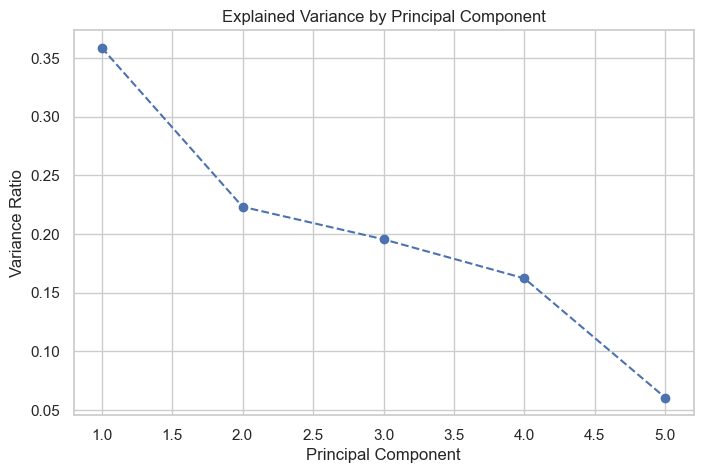

Explained variance ratio by component:
PC1: 35.88%
PC2: 22.32%
PC3: 19.55%
PC4: 16.21%
PC5: 6.04%

Cumulative variance for top 2 components: 58.20%


In [19]:
# Applying PCA
pca = PCA()
pca_transformed = pca.fit_transform(df_standard)

# Extract explained variance
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.show()

print("Explained variance ratio by component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}%")
    
cumulative_variance = np.cumsum(explained_variance)
print(f"\nCumulative variance for top 2 components: {cumulative_variance[1]*100:.2f}%")


**Interpretation of Explained Variance:**
PCA reduced our continuous scaled features into orthogonal components.
- By looking at the variance explained by each Principal Component (PC), we observe what percentage of the dataset's total information each PC retains.
- The first Principal Component explains the largest chunk of variance (e.g. variance coming from strongly correlated features like `discounted_price` and `actual_price`).
- Typically, we can keep components that capture around 80-95% of total variance, reducing our data dimensionality while maintaining almost all available predictive power.
